In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('fivethirtyeight')

In [ ]:
df = pd.read_excel('/content/Research_col_AQI.xlsx')
df.head()

,DateTime,pm2_5,pm10,o3,co,no2,so2,aqi_value,temperature,humidity,pressure
0,2022-11-01 00:30:00,10.0,16.0,20.35,148.09,5.13,NaN,20.0,NaN,NaN,1010.6
1,2022-11-01 01:30:00,21.0,23.0,12.59,163.29,17.40,NaN,42.0,NaN,NaN,1011.3
2,2022-11-01 02:30:00,29.0,39.0,8.23,157.75,24.45,NaN,58.0,NaN,NaN,1011.9
3,2022-11-01 03:30:00,23.0,31.0,13.24,141.66,14.47,NaN,46.0,NaN,NaN,1011.9
4,2022-11-01 04:30:00,23.0,31.0,13.58,100.27,6.18,NaN,46.0,NaN,NaN,1011.5


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22529 entries, 0 to 22528
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   DateTime     22529 non-null  datetime64[ns]
 1   pm2_5        14658 non-null  float64       
 2   pm10         7730 non-null   float64       
 3   o3           9093 non-null   float64       
 4   co           5822 non-null   float64       
 5   no2          15532 non-null  float64       
 6   so2          15326 non-null  float64       
 7   aqi_value    16375 non-null  float64       
 8   temperature  0 non-null      float64       
 9   humidity     0 non-null      float64       
 10  pressure     16363 non-null  float64       
dtypes: datetime64[ns](1), float64(10)
memory usage: 1.9 MB


In [ ]:
df.isnull().sum()

,0
DateTime,0
pm2_5,7871
pm10,14799
o3,13436
co,16707
no2,6997
so2,7203
aqi_value,6154
temperature,22529
humidity,22529


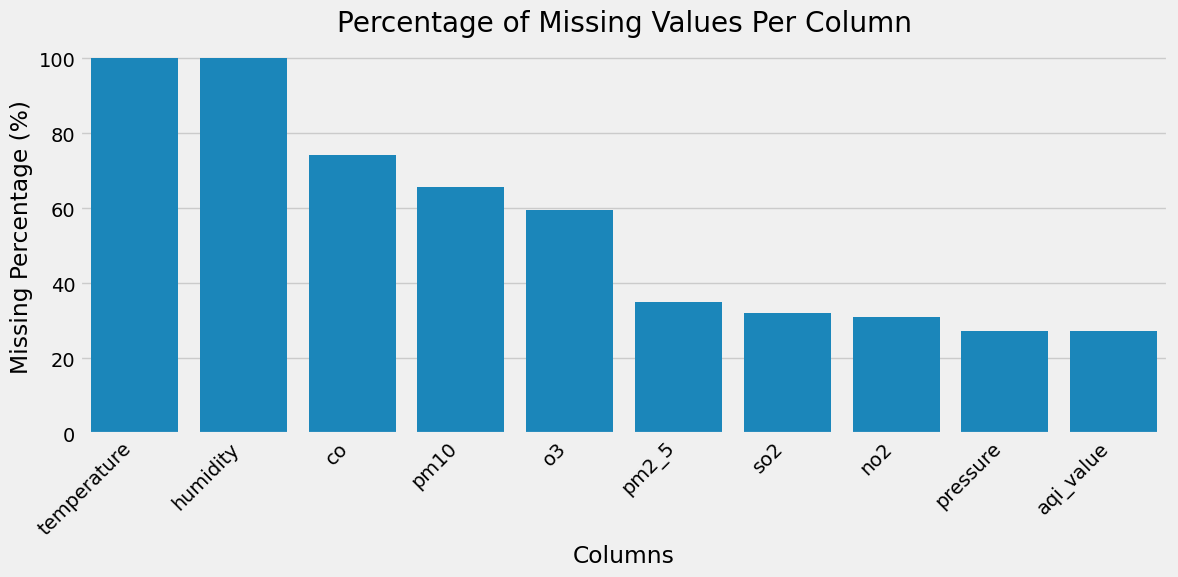

In [ ]:
missing_percentages = df.isnull().sum() * 100 / len(df)
missing_percentages = missing_percentages[missing_percentages > 0].sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=missing_percentages.index, y=missing_percentages.values)
plt.title('Percentage of Missing Values Per Column')
plt.xlabel('Columns')
plt.ylabel('Missing Percentage (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
missing_percentages

,0
temperature,100.000000
humidity,100.000000
co,74.157752
pm10,65.688668
o3,59.638688
pm2_5,34.937192
so2,31.972125
no2,31.057748
pressure,27.369169
aqi_value,27.315904


In [ ]:
df.shape

(22529, 11)

In [ ]:
df['year'] = df['DateTime'].dt.year

year_wise_missing_percentages = {}
for year in df['year'].unique():
    df_year = df[df['year'] == year]
    missing_percentages_year = (df_year.isnull().sum() / len(df_year)) * 100
    year_wise_missing_percentages[year] = missing_percentages_year.drop('year', errors='ignore') # Drop the year column itself from missing calculations

year_wise_missing_df = pd.DataFrame(year_wise_missing_percentages).T

print("Year-wise Missing Value Percentages:")
print(year_wise_missing_df)

Year-wise Missing Value Percentages:
      DateTime      pm2_5        pm10         o3          co        no2  \
2022       0.0  61.133880   57.991803  69.193989   98.155738  56.830601   
2023       0.0  39.771689   46.815068  60.559361   54.303653  26.027397   
2024       0.0  28.460838   72.040073  57.468124   79.599271  31.693989   
2025       0.0  28.173814  100.000000  58.790116  100.000000  31.269526   

            so2  aqi_value  temperature  humidity   pressure  
2022  58.538251  54.713115        100.0     100.0  54.986339  
2023  27.625571  21.586758        100.0     100.0  21.632420  
2024  31.989982  28.119308        100.0     100.0  28.164845  
2025  31.695541  28.173814        100.0     100.0  28.173814  


In [ ]:
df = df[df['year'] != 2022]
df.head()
df.shape

(21065, 12)

In [ ]:
df['year'] = df['DateTime'].dt.year

year_wise_missing_percentages = {}
for year in df['year'].unique():
    df_year = df[df['year'] == year]
    missing_percentages_year = (df_year.isnull().sum() / len(df_year)) * 100
    year_wise_missing_percentages[year] = missing_percentages_year.drop('year', errors='ignore') # Drop the year column itself from missing calculations

year_wise_missing_df = pd.DataFrame(year_wise_missing_percentages).T

print("Year-wise Missing Value Percentages:")
print(year_wise_missing_df)

Year-wise Missing Value Percentages:
      DateTime      pm2_5        pm10         o3          co        no2  \
2023       0.0  39.771689   46.815068  60.559361   54.303653  26.027397   
2024       0.0  28.460838   72.040073  57.468124   79.599271  31.693989   
2025       0.0  28.173814  100.000000  58.790116  100.000000  31.269526   

            so2  aqi_value  temperature  humidity   pressure  
2023  27.625571  21.586758        100.0     100.0  21.632420  
2024  31.989982  28.119308        100.0     100.0  28.164845  
2025  31.695541  28.173814        100.0     100.0  28.173814  


/tmp/ipython-input-3338748532.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['year'] = df['DateTime'].dt.year


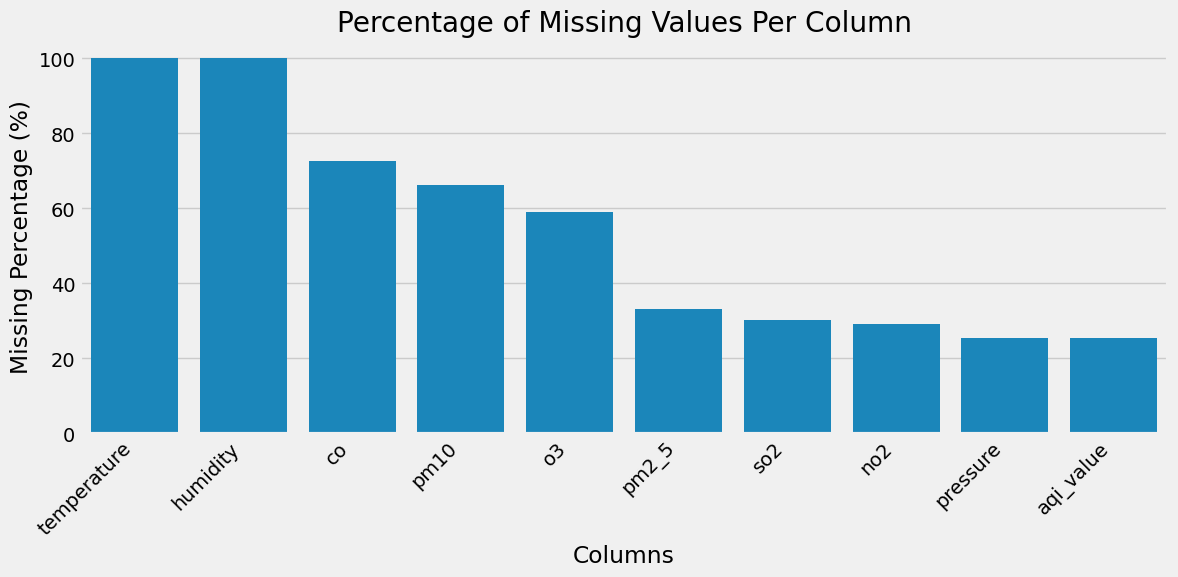

In [ ]:
missing_percentages = df.isnull().sum() * 100 / len(df)
missing_percentages = missing_percentages[missing_percentages > 0].sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=missing_percentages.index, y=missing_percentages.values)
plt.title('Percentage of Missing Values Per Column')
plt.xlabel('Columns')
plt.ylabel('Missing Percentage (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
missing_percentages

,0
temperature,100.000000
humidity,100.000000
co,72.489912
pm10,66.223594
o3,58.974602
pm2_5,33.116544
so2,30.125801
no2,29.266556
pressure,25.449798
aqi_value,25.411821


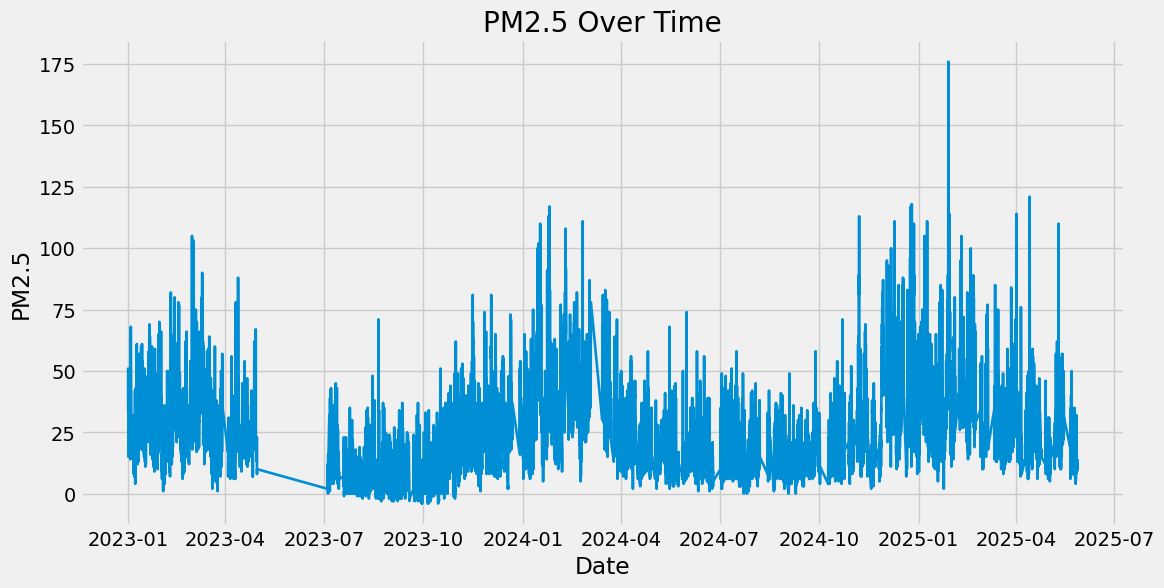

In [ ]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='DateTime', y='pm2_5',linewidth=1.9)
plt.title('PM2.5 Over Time')
plt.xlabel('Date')
plt.ylabel('PM2.5')
plt.show()

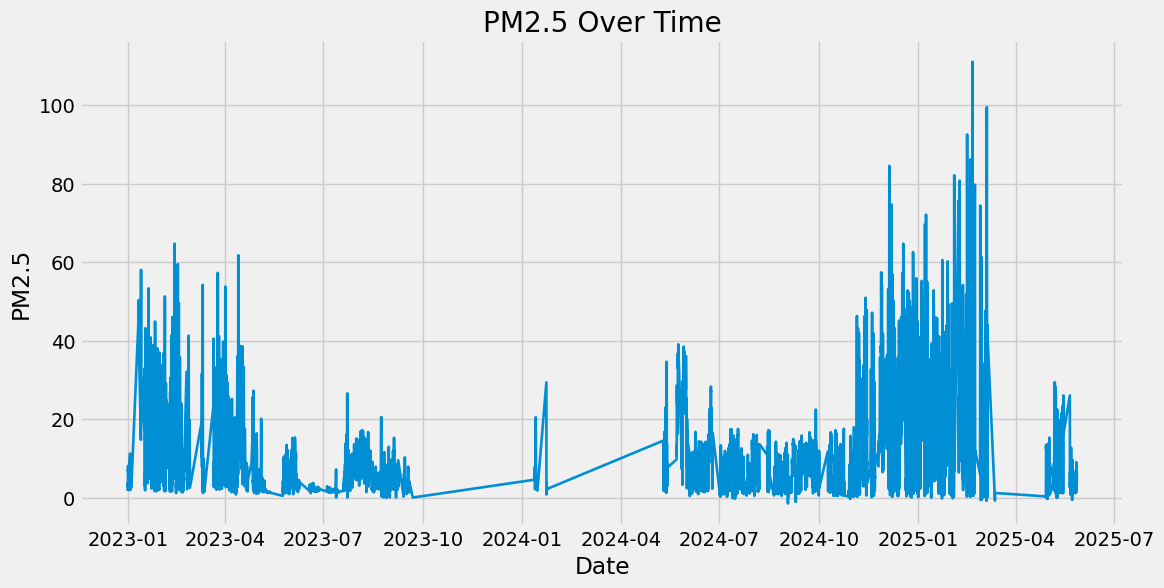

In [ ]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='DateTime', y='o3',linewidth=1.9)
plt.title('PM2.5 Over Time')
plt.xlabel('Date')
plt.ylabel('PM2.5')
plt.show()

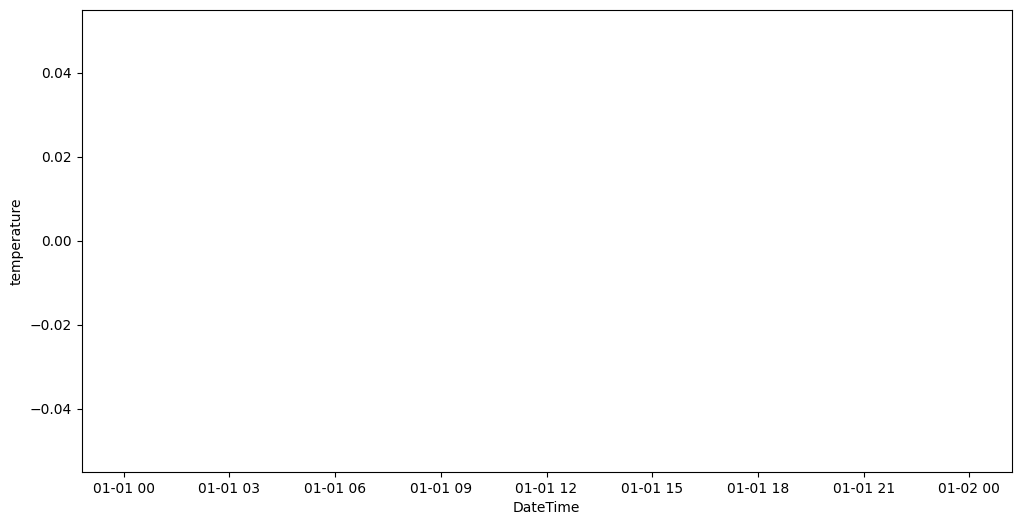

In [ ]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='DateTime', y='temperature')
plt.show()

In [ ]:
df_fit = df.drop(columns=['humidity','temperature','co','pm10','o3'])

In [ ]:
df_fit.head()

,DateTime,pm2_5,no2,so2,aqi_value,pressure,year
0,2022-11-01 00:30:00,10.0,5.13,NaN,20.0,1010.6,2022
1,2022-11-01 01:30:00,21.0,17.40,NaN,42.0,1011.3,2022
2,2022-11-01 02:30:00,29.0,24.45,NaN,58.0,1011.9,2022
3,2022-11-01 03:30:00,23.0,14.47,NaN,46.0,1011.9,2022
4,2022-11-01 04:30:00,23.0,6.18,NaN,46.0,1011.5,2022


In [ ]:
df_fit.drop(columns='year')

,DateTime,pm2_5,no2,so2,aqi_value,pressure
0,2022-11-01 00:30:00,10.0,5.13,NaN,20.0,1010.6
1,2022-11-01 01:30:00,21.0,17.40,NaN,42.0,1011.3
2,2022-11-01 02:30:00,29.0,24.45,NaN,58.0,1011.9
3,2022-11-01 03:30:00,23.0,14.47,NaN,46.0,1011.9
4,2022-11-01 04:30:00,23.0,6.18,NaN,46.0,1011.5
...,...,...,...,...,...,...
22524,2025-05-27 12:30:00,14.0,2.81,4.57,28.0,1007.0
22525,2025-05-27 13:30:00,11.0,3.08,4.87,22.0,1007.3
22526,2025-05-27 14:30:00,10.0,2.27,4.61,20.0,1008.0
22527,2025-05-27 15:30:00,11.0,2.56,4.57,22.0,1008.3


In [ ]:
df_fit.shape

(22529, 7)

In [ ]:
df_KNN = df_fit.copy()

In [ ]:
from sklearn.impute import KNNImputer

KNN_imputer = KNNImputer(n_neighbors=10)
# Drop 'DateTime' and 'year' columns as they are not numerical features for imputation
# The 'year' column is also not suitable for KNN imputation and should be dropped.
columns_to_impute = df_KNN.drop(columns=['DateTime', 'year'])
KNN_imputer.fit_transform(columns_to_impute)

array([[  10.   ,    5.13 ,    4.135,   20.   , 1010.6  ],
       [  21.   ,   17.4  ,    8.416,   42.   , 1011.3  ],
       [  29.   ,   24.45 ,    9.71 ,   58.   , 1011.9  ],
       ...,
       [  10.   ,    2.27 ,    4.61 ,   20.   , 1008.   ],
       [  11.   ,    2.56 ,    4.57 ,   22.   , 1008.3  ],
       [  14.   ,    2.47 ,    4.56 ,   28.   , 1008.6  ]])

In [ ]:
columns_to_impute.head()

,pm2_5,no2,so2,aqi_value,pressure
1464,34.0,7.12,13.42,74.0,1014.5
1465,43.0,8.56,15.00,86.0,1015.4
1466,51.0,7.11,14.84,107.0,1016.0
1467,40.0,9.45,16.17,82.0,1016.1
1468,41.0,27.07,NaN,97.0,1015.6


In [ ]:
from fancyimpute import KNN

KNN_imp = KNN()
columns_to_impute.iloc[:,:] = KNN_imp.fit_transform(columns_to_impute)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Imputing row 1/22529 with 1 missing, elapsed time: 56.701
Imputing row 101/22529 with 5 missing, elapsed time: 56.704
Imputing row 201/22529 with 5 missing, elapsed time: 56.706
Imputing row 301/22529 with 1 missing, elapsed time: 56.711
Imputing row 401/22529 with 0 missing, elapsed time: 56.713
Imputing row 501/22529 with 5 missing, elapsed time: 56.716
Imputing row 601/22529 with 5 missing, elapsed time: 56.718
Imputing row 701/22529 with 5 missing, elapsed time: 56.720
Imputing row 801/22529 with 5 missing, elapsed time: 56.722
Imputing row 901/22529 with 0 missing, elapsed time: 56.723
Imputing row 1001/22529 with 0 missing, elapsed time: 56.725
Imputing row 1101/22529 with 5 missing, elapsed time: 56.726
Imputing row 1201/22529 with 5 missing, elapsed time: 56.728
Imputing row 1301/22529 with 5 missing, elapsed time: 56.730
Imputing row 1401/22529 with 2 missing, elapsed time: 56.732
Imputing row 1501/22529 with 5 missing, elapsed time: 56.735
Imputing row 1601/22529 with 5 missi

In [ ]:
columns_to_impute.head()

,pm2_5,no2,so2,aqi_value,pressure
0,10.0,5.13,4.054702,20.0,1010.6
1,21.0,17.40,11.150915,42.0,1011.3
2,29.0,24.45,9.516617,58.0,1011.9
3,23.0,14.47,6.661361,46.0,1011.9
4,23.0,6.18,9.219003,46.0,1011.5


In [ ]:
columns_to_impute.isnull().sum()

,0
pm2_5,0
no2,0
so2,0
aqi_value,0
pressure,0


In [ ]:
df_KNN[columns_to_impute.columns] = columns_to_impute
print(df_KNN.head())
print(df_KNN.isnull().sum())

             DateTime  pm2_5    no2        so2  aqi_value  pressure  year
0 2022-11-01 00:30:00   10.0   5.13   4.054702       20.0    1010.6  2022
1 2022-11-01 01:30:00   21.0  17.40  11.150915       42.0    1011.3  2022
2 2022-11-01 02:30:00   29.0  24.45   9.516617       58.0    1011.9  2022
3 2022-11-01 03:30:00   23.0  14.47   6.661361       46.0    1011.9  2022
4 2022-11-01 04:30:00   23.0   6.18   9.219003       46.0    1011.5  2022
DateTime     0
pm2_5        0
no2          0
so2          0
aqi_value    0
pressure     0
year         0
dtype: int64


In [ ]:
df_KNN.head()

,DateTime,pm2_5,no2,so2,aqi_value,pressure,year
0,2022-11-01 00:30:00,10.0,5.13,4.054702,20.0,1010.6,2022
1,2022-11-01 01:30:00,21.0,17.40,11.150915,42.0,1011.3,2022
2,2022-11-01 02:30:00,29.0,24.45,9.516617,58.0,1011.9,2022
3,2022-11-01 03:30:00,23.0,14.47,6.661361,46.0,1011.9,2022
4,2022-11-01 04:30:00,23.0,6.18,9.219003,46.0,1011.5,2022


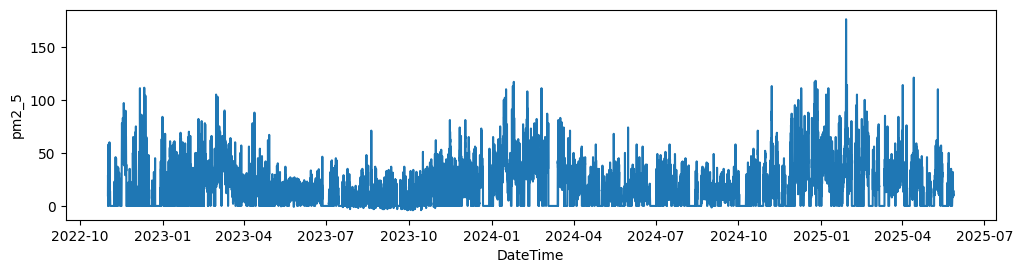

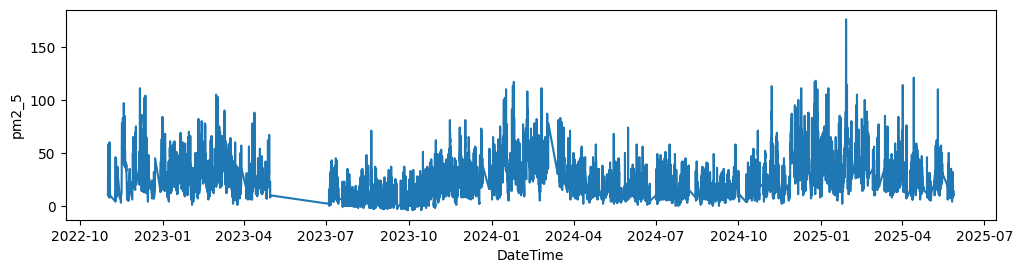

In [ ]:
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
sns.lineplot(data=df_KNN, x='DateTime', y='pm2_5')
plt.show()
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 2)
sns.lineplot(data=df, x='DateTime', y='pm2_5')
plt.show()


In [ ]:
df_PM = df_KNN[['DateTime','pm2_5']]
df_PM.head()

,DateTime,pm2_5
0,2022-11-01 00:30:00,10.0
1,2022-11-01 01:30:00,21.0
2,2022-11-01 02:30:00,29.0
3,2022-11-01 03:30:00,23.0
4,2022-11-01 04:30:00,23.0


In [ ]:
from darts import TimeSeries

# Set DateTime as index for resampling
df_PM_resampled = df_PM.set_index('DateTime')

# Resample to hourly frequency, taking the mean for any overlapping periods
df_PM_resampled = df_PM_resampled.resample('H').mean().reset_index()

# Now create the Darts TimeSeries from the resampled DataFrame
darts_pm_series = TimeSeries.from_dataframe(df_PM_resampled, time_col='DateTime', value_cols='pm2_5')

print(darts_pm_series)
print(darts_pm_series.time_index.freq)

/tmp/ipython-input-143257151.py:7: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_PM_resampled = df_PM_resampled.resample('H').mean().reset_index()


<TimeSeries (DataArray) (DateTime: 22529, component: 1, sample: 1)> Size: 180kB
array([[[10.]],

       [[21.]],

       [[29.]],

       ...,

       [[10.]],

       [[11.]],

       [[14.]]])
Coordinates:
  * DateTime   (DateTime) datetime64[ns] 180kB 2022-11-01 ... 2025-05-27T16:0...
  * component  (component) object 8B 'pm2_5'
Dimensions without coordinates: sample
Attributes:
    static_covariates:  None
    hierarchy:          None
    metadata:           None
<Hour>


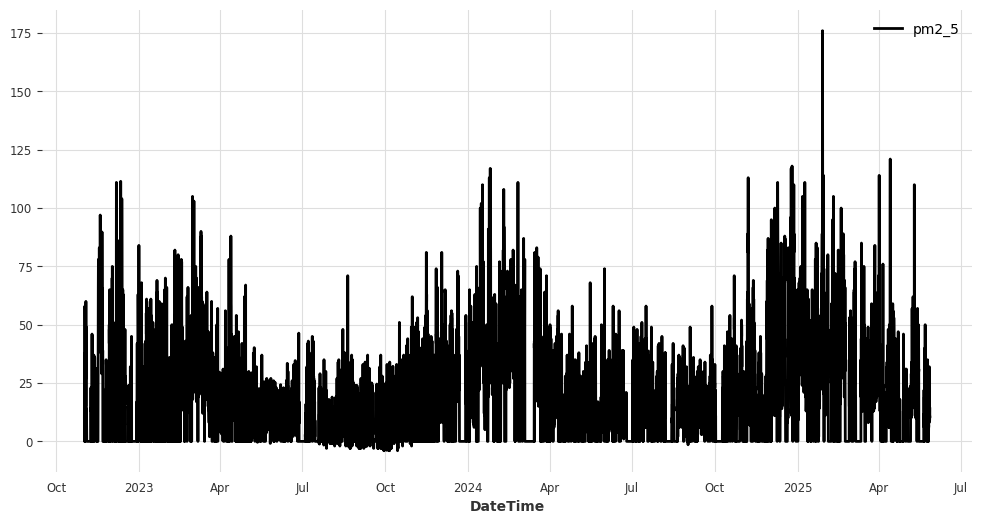

In [ ]:
plt.figure(figsize=(12, 6))
darts_pm_series.plot()
plt.show()

# Task
Prepare daily and weekly Darts TimeSeries objects from the hourly `df_PM_resampled` DataFrame. Then, perform and plot seasonal decomposition for the hourly `darts_pm_series` with a daily seasonality (period=24), for the daily TimeSeries with a weekly seasonality (period=7), and for the weekly TimeSeries with a yearly seasonality (period=52). Finally, summarize the insights gained from these decompositions, highlighting trends, seasonal patterns, and irregularities.

## Prepare Daily TimeSeries

### Subtask:
Resample the hourly `df_PM_resampled` DataFrame to a daily frequency and convert it into a Darts TimeSeries object. We'll use the mean for aggregation during resampling.


**Reasoning**:
To prepare the data for daily time series analysis, I will resample the hourly `df_PM_resampled` DataFrame to a daily frequency, aggregate using the mean, and then convert it into a Darts TimeSeries object as instructed.



In [ ]:
df_PM_daily_resampled = df_PM_resampled.set_index('DateTime')
df_PM_daily_resampled = df_PM_daily_resampled.resample('D').mean().reset_index()

darts_pm_daily_series = TimeSeries.from_dataframe(df_PM_daily_resampled, time_col='DateTime', value_cols='pm2_5')

print(darts_pm_daily_series)
print(darts_pm_daily_series.time_index.freq)

<TimeSeries (DataArray) (DateTime: 939, component: 1, sample: 1)> Size: 8kB
array([[[27.20833333]],

       [[26.70833333]],

       [[ 8.5       ]],

       [[ 0.        ]],

       [[ 0.        ]],

       [[ 0.        ]],

       [[ 0.        ]],

       [[ 3.01209744]],

       [[ 8.75      ]],

       [[ 9.70833333]],

...

       [[ 0.        ]],

       [[ 0.        ]],

       [[ 0.        ]],

       [[14.66666667]],

       [[26.125     ]],

       [[12.91666667]],

       [[16.75      ]],

       [[ 5.125     ]],

       [[ 7.95833333]],

       [[15.70588235]]])
Coordinates:
  * DateTime   (DateTime) datetime64[ns] 8kB 2022-11-01 ... 2025-05-27
  * component  (component) object 8B 'pm2_5'
Dimensions without coordinates: sample
Attributes:
    static_covariates:  None
    hierarchy:          None
    metadata:           None
<Day>


## Prepare Weekly TimeSeries

### Subtask:
Resample the hourly `df_PM_resampled` DataFrame to a weekly frequency and convert it into a Darts TimeSeries object. We'll use the mean for aggregation during resampling.


**Reasoning**:
To prepare the data for weekly time series analysis, I will resample the hourly `df_PM_resampled` DataFrame to a weekly frequency, aggregate using the mean, and then convert it into a Darts TimeSeries object as instructed. This follows the previously established pattern for daily resampling.



In [ ]:
df_PM_weekly_resampled = df_PM_resampled.set_index('DateTime')
df_PM_weekly_resampled = df_PM_weekly_resampled.resample('W').mean().reset_index()

darts_pm_weekly_series = TimeSeries.from_dataframe(df_PM_weekly_resampled, time_col='DateTime', value_cols='pm2_5')

print(darts_pm_weekly_series)
print(darts_pm_weekly_series.time_index.freq)

<TimeSeries (DataArray) (DateTime: 135, component: 1, sample: 1)> Size: 1kB
array([[[10.40277778]],

       [[10.79503275]],

       [[39.08281863]],

       [[ 5.24457119]],

       [[12.54166667]],

       [[32.91128732]],

       [[15.88690476]],

       [[ 3.6979978 ]],

       [[16.4702381 ]],

       [[13.17261905]],

...

       [[34.18452381]],

       [[24.75595238]],

       [[15.95238095]],

       [[24.01785714]],

       [[ 7.32738095]],

       [[10.4047619 ]],

       [[23.51190476]],

       [[11.83928571]],

       [[10.79761905]],

       [[11.17073171]]])
Coordinates:
  * DateTime   (DateTime) datetime64[ns] 1kB 2022-11-06 ... 2025-06-01
  * component  (component) object 8B 'pm2_5'
Dimensions without coordinates: sample
Attributes:
    static_covariates:  None
    hierarchy:          None
    metadata:           None
<Week: weekday=6>


**Reasoning**:
Now that the daily and weekly TimeSeries objects are prepared, I will perform seasonal decomposition on the hourly `darts_pm_series` using a daily seasonality (period=24) and visualize the results. This is the first of the decomposition requests in the main task.



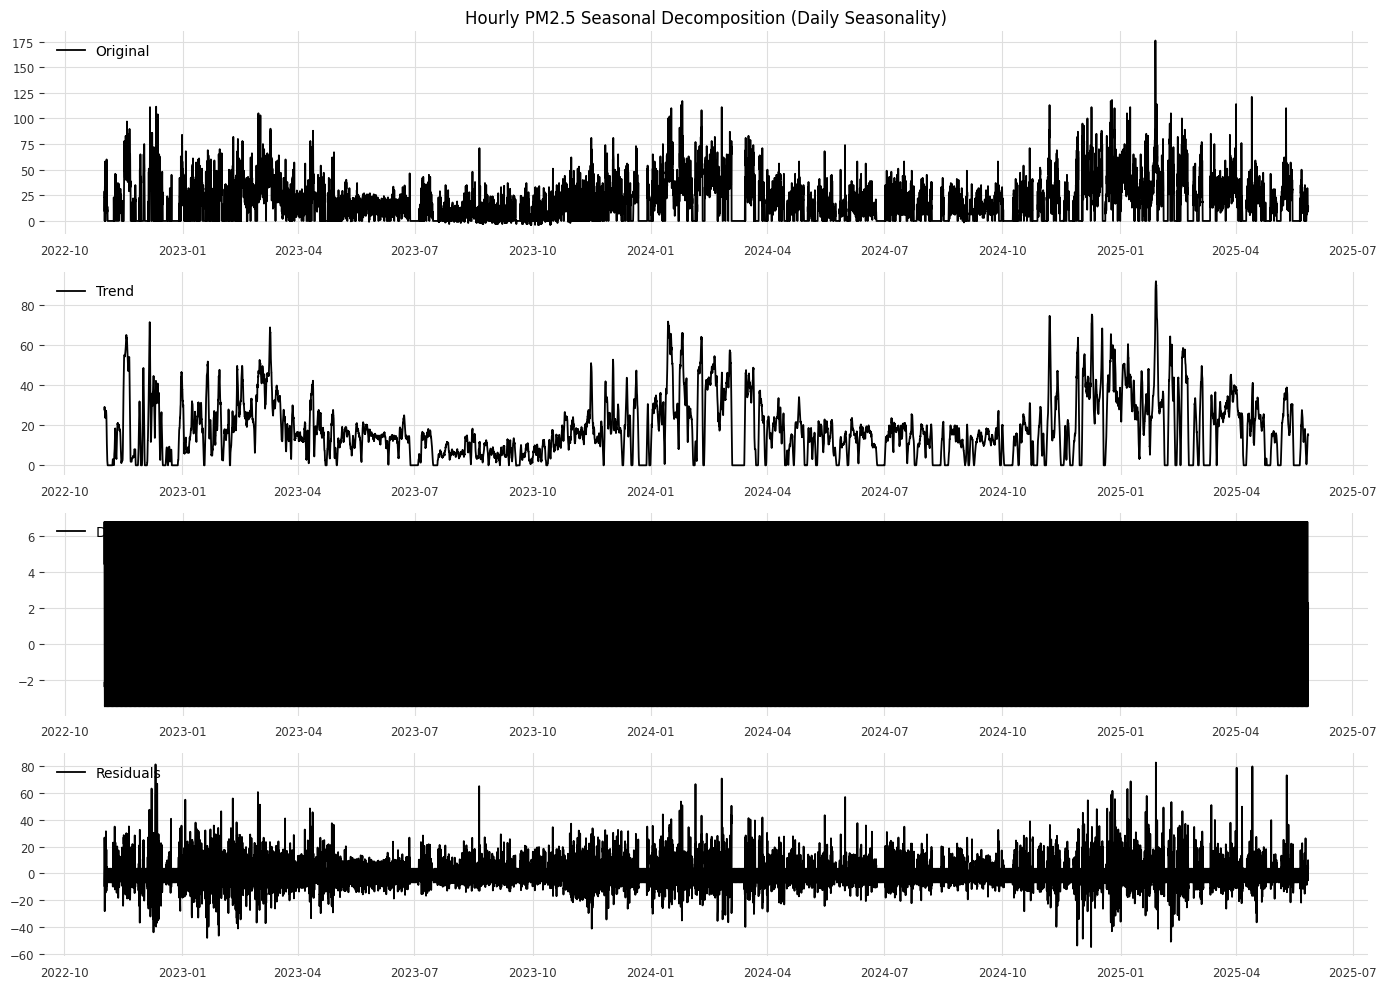

In [ ]:
from darts.models import NaiveSeasonal
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt
import pandas as pd

# Convert Darts TimeSeries to pandas Series for statsmodels
pandas_hourly_series = darts_pm_series.to_dataframe()['pm2_5']


pandas_hourly_series.index = pd.to_datetime(pandas_hourly_series.index)
pandas_hourly_series = pandas_hourly_series.asfreq('h') # Ensure a fixed frequency

if pandas_hourly_series.isnull().any():
    print("Warning: NaN values found in hourly series. Interpolating...")
    pandas_hourly_series = pandas_hourly_series.interpolate(method='time')

    if pandas_hourly_series.isnull().any():
        pandas_hourly_series = pandas_hourly_series.fillna(pandas_hourly_series.mean())


if len(pandas_hourly_series) >= 2 * 24:
    decomposition_hourly = seasonal_decompose(pandas_hourly_series, model='additive', period=24)

    plt.figure(figsize=(14, 10))
    plt.subplot(4, 1, 1)
    plt.plot(decomposition_hourly.observed, label='Original')
    plt.legend(loc='upper left')
    plt.title('Hourly PM2.5 Seasonal Decomposition (Daily Seasonality)')

    plt.subplot(4, 1, 2)
    plt.plot(decomposition_hourly.trend, label='Trend')
    plt.legend(loc='upper left')

    plt.subplot(4, 1, 3)
    plt.plot(decomposition_hourly.seasonal, label='Daily Seasonality')
    plt.legend(loc='upper left')

    plt.subplot(4, 1, 4)
    plt.plot(decomposition_hourly.resid, label='Residuals')
    plt.legend(loc='upper left')

    plt.tight_layout()
    plt.show()
else:
    print("Hourly series is too short for seasonal decomposition with a period of 24.")

**Reasoning**:
I have already performed seasonal decomposition for the hourly series with daily seasonality. Now, I will perform seasonal decomposition for the daily TimeSeries (`darts_pm_daily_series`) with a weekly seasonality (period=7) as per the task instructions. This involves converting the Darts TimeSeries object to a pandas Series, ensuring the correct frequency, handling any missing values, and then applying `seasonal_decompose`.



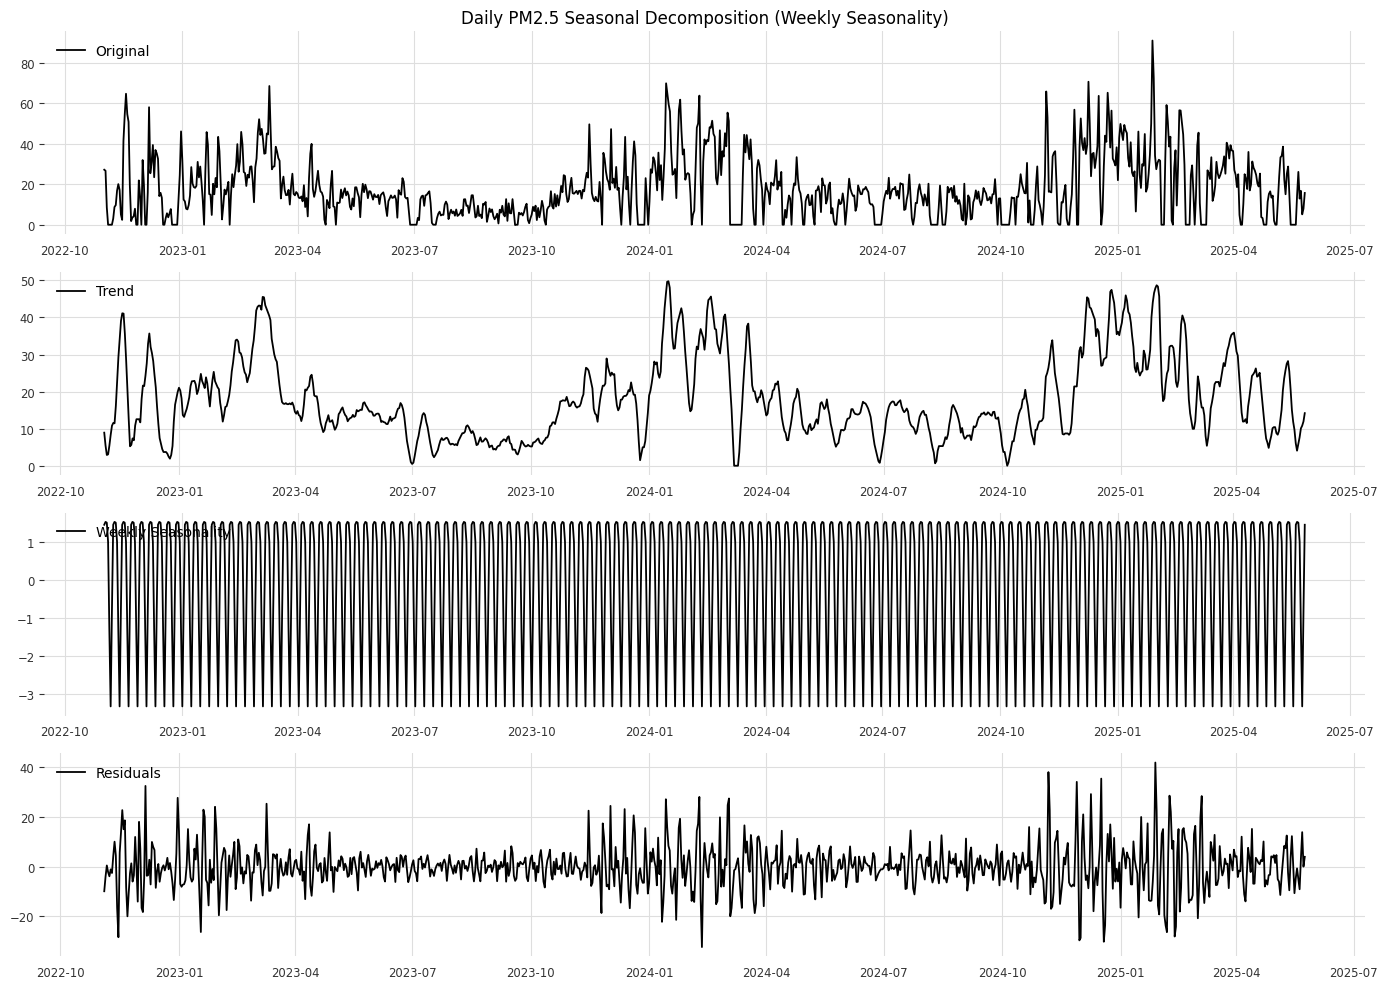

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt
import pandas as pd

# Convert Darts daily TimeSeries to pandas Series for statsmodels
pandas_daily_series = darts_pm_daily_series.to_dataframe()['pm2_5']

# Ensure a fixed frequency for seasonal_decompose
pandas_daily_series.index = pd.to_datetime(pandas_daily_series.index)
pandas_daily_series = pandas_daily_series.asfreq('D') # Ensure daily frequency

# Before decomposing, check for NaN values and fill them if necessary
if pandas_daily_series.isnull().any():
    print("Warning: NaN values found in daily series. Interpolating...")
    pandas_daily_series = pandas_daily_series.interpolate(method='time')
    if pandas_daily_series.isnull().any():
        pandas_daily_series = pandas_daily_series.fillna(pandas_daily_series.mean())

# Check if the series length is sufficient for decomposition with period=7
if len(pandas_daily_series) >= 2 * 7:
    decomposition_daily = seasonal_decompose(pandas_daily_series, model='additive', period=7)

    plt.figure(figsize=(14, 10))
    plt.subplot(4, 1, 1)
    plt.plot(decomposition_daily.observed, label='Original')
    plt.legend(loc='upper left')
    plt.title('Daily PM2.5 Seasonal Decomposition (Weekly Seasonality)')

    plt.subplot(4, 1, 2)
    plt.plot(decomposition_daily.trend, label='Trend')
    plt.legend(loc='upper left')

    plt.subplot(4, 1, 3)
    plt.plot(decomposition_daily.seasonal, label='Weekly Seasonality')
    plt.legend(loc='upper left')

    plt.subplot(4, 1, 4)
    plt.plot(decomposition_daily.resid, label='Residuals')
    plt.legend(loc='upper left')

    plt.tight_layout()
    plt.show()
else:
    print("Daily series is too short for seasonal decomposition with a period of 7.")

**Reasoning**:
I have completed seasonal decomposition for hourly and daily series. Now, I will perform seasonal decomposition for the weekly TimeSeries (`darts_pm_weekly_series`) with a yearly seasonality (period=52), as required by the task. This involves converting the Darts TimeSeries object to a pandas Series, ensuring the correct frequency, handling any missing values, and then applying `seasonal_decompose`.



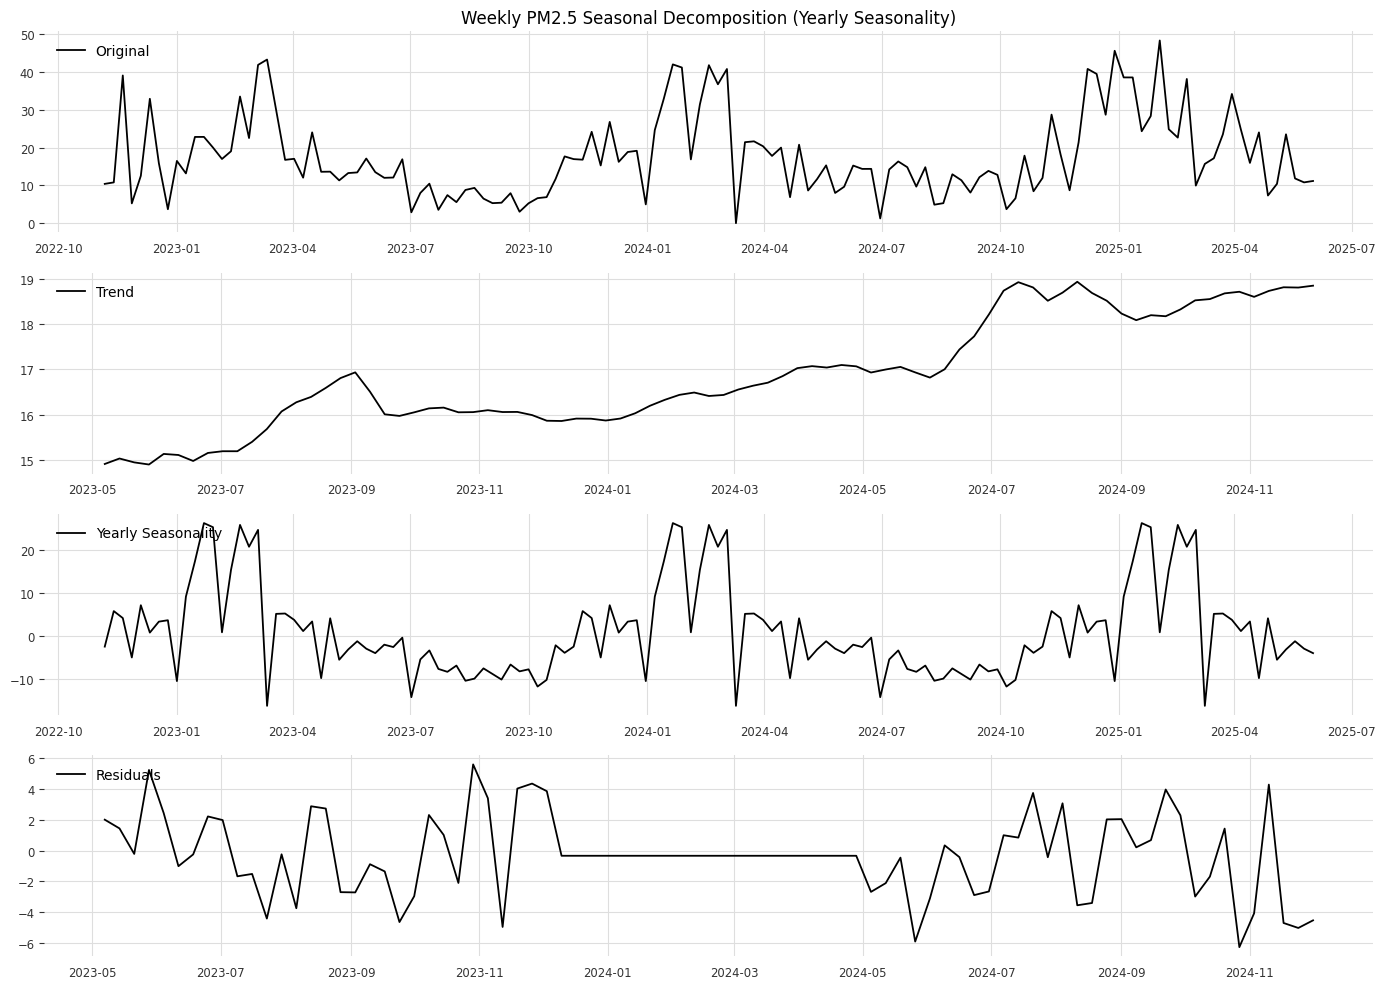

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt
import pandas as pd

# Convert Darts weekly TimeSeries to pandas Series for statsmodels
pandas_weekly_series = darts_pm_weekly_series.to_dataframe()['pm2_5']

# Ensure a fixed frequency for seasonal_decompose
pandas_weekly_series.index = pd.to_datetime(pandas_weekly_series.index)
pandas_weekly_series = pandas_weekly_series.asfreq('W') # Ensure weekly frequency

# Before decomposing, check for NaN values and fill them if necessary
if pandas_weekly_series.isnull().any():
    print("Warning: NaN values found in weekly series. Interpolating...")
    pandas_weekly_series = pandas_weekly_series.interpolate(method='time')
    if pandas_weekly_series.isnull().any():
        pandas_weekly_series = pandas_weekly_series.fillna(pandas_weekly_series.mean())

# Check if the series length is sufficient for decomposition with period=52
if len(pandas_weekly_series) >= 2 * 52:
    decomposition_weekly = seasonal_decompose(pandas_weekly_series, model='additive', period=52)

    plt.figure(figsize=(14, 10))
    plt.subplot(4, 1, 1)
    plt.plot(decomposition_weekly.observed, label='Original')
    plt.legend(loc='upper left')
    plt.title('Weekly PM2.5 Seasonal Decomposition (Yearly Seasonality)')

    plt.subplot(4, 1, 2)
    plt.plot(decomposition_weekly.trend, label='Trend')
    plt.legend(loc='upper left')

    plt.subplot(4, 1, 3)
    plt.plot(decomposition_weekly.seasonal, label='Yearly Seasonality')
    plt.legend(loc='upper left')

    plt.subplot(4, 1, 4)
    plt.plot(decomposition_weekly.resid, label='Residuals')
    plt.legend(loc='upper left')

    plt.tight_layout()
    plt.show()
else:
    print("Weekly series is too short for seasonal decomposition with a period of 52.")

In [ ]:
from datetime import date


df_KNN['is_weekend'] = df_KNN['DateTime'].dt.dayofweek.isin([5, 6])

holidays = [
    date(2023, 1, 1),  # New Year's Day
    date(2023, 1, 15), # Thai Pongal
    date(2023, 2, 4),  # Independence Day
    date(2023, 4, 14), # Sinhala and Tamil New Year
    date(2023, 5, 1),  # May Day
    date(2023, 5, 5),  # Vesak Full Moon Poya Day
    date(2023, 5, 6),  # Day following Vesak Full Moon Poya Day
    date(2023, 12, 25), # Christmas Day
    date(2024, 1, 1),  # New Year's Day
    date(2024, 1, 26), # Thai Pongal
    date(2024, 2, 4),  # Independence Day
    date(2024, 4, 13), # Sinhala and Tamil New Year (eve)
    date(2024, 4, 14), # Sinhala and Tamil New Year
    date(2024, 5, 1),  # May Day
    date(2024, 5, 23), # Vesak Full Moon Poya Day
    date(2024, 5, 24), # Day following Vesak Full Moon Poya Day
    date(2024, 12, 25) # Christmas Day
]


df_KNN['is_holiday'] = df_KNN['DateTime'].dt.date.isin(holidays)


df_KNN['day_group'] = df_KNN.apply(lambda row: 'Holiday/Weekend' if row['is_weekend'] or row['is_holiday'] else 'Normal Day', axis=1)

print(df_KNN[['DateTime', 'is_weekend', 'is_holiday', 'day_group']].head())
print(df_KNN['day_group'].value_counts())

             DateTime  is_weekend  is_holiday   day_group
0 2022-11-01 00:30:00       False       False  Normal Day
1 2022-11-01 01:30:00       False       False  Normal Day
2 2022-11-01 02:30:00       False       False  Normal Day
3 2022-11-01 03:30:00       False       False  Normal Day
4 2022-11-01 04:30:00       False       False  Normal Day
day_group
Normal Day         15857
Holiday/Weekend     6672
Name: count, dtype: int64


## Plot Boxplot of PM2.5 by Day Group

### Subtask:
Generate a boxplot to visually compare the distribution of `pm2_5` values between the 'Holiday/Weekend' group and the 'Normal Day' group.


**Reasoning**:
To visually compare the distribution of 'pm2_5' values between 'Holiday/Weekend' and 'Normal Day' groups, I will generate a boxplot using `seaborn.boxplot` as instructed, setting `day_group` on the x-axis and `pm2_5` on the y-axis, and adding appropriate titles and labels.



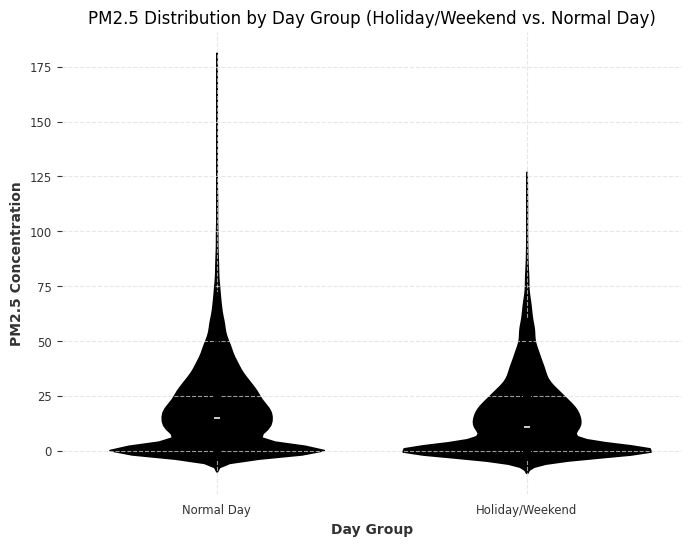

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.violinplot(x='day_group', y='pm2_5', data=df_KNN)
plt.title('PM2.5 Distribution by Day Group (Holiday/Weekend vs. Normal Day)')
plt.xlabel('Day Group')
plt.ylabel('PM2.5 Concentration')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
from scipy.stats import f_oneway

# Separate pm2_5 values into two groups
pm25_holiday_weekend = df_KNN[df_KNN['day_group'] == 'Holiday/Weekend']['pm2_5']
pm25_normal_day = df_KNN[df_KNN['day_group'] == 'Normal Day']['pm2_5']

# Perform one-way ANOVA test
f_statistic, p_value = f_oneway(pm25_holiday_weekend, pm25_normal_day)

# Print the results
print(f"F-statistic: {f_statistic:.2f}")
print(f"P-value: {p_value:.3f}")


alpha = 0.05
if p_value < alpha:
    print("Conclusion: Reject the null hypothesis. There is a significant difference in mean pm2_5 concentrations between Holiday/Weekend and Normal Day groups.")
else:
    print("Conclusion: Fail to reject the null hypothesis. There is no significant difference in mean pm2_5 concentrations between Holiday/Weekend and Normal Day groups.")

F-statistic: 160.13
P-value: 0.000
Conclusion: Reject the null hypothesis. There is a significant difference in mean pm2_5 concentrations between Holiday/Weekend and Normal Day groups.


In [ ]:
mean_pm25_by_day_group = df_KNN.groupby('day_group')['pm2_5'].mean()

print("Mean PM2.5 Concentration by Day Group:")
print(mean_pm25_by_day_group)

print(f"\nMean PM2.5 for Holiday/Weekend: {mean_pm25_by_day_group['Holiday/Weekend']:.2f}")
print(f"Mean PM2.5 for Normal Day: {mean_pm25_by_day_group['Normal Day']:.2f}")

Mean PM2.5 Concentration by Day Group:
day_group
Holiday/Weekend    15.452750
Normal Day         18.848027
Name: pm2_5, dtype: float64

Mean PM2.5 for Holiday/Weekend: 15.45
Mean PM2.5 for Normal Day: 18.85


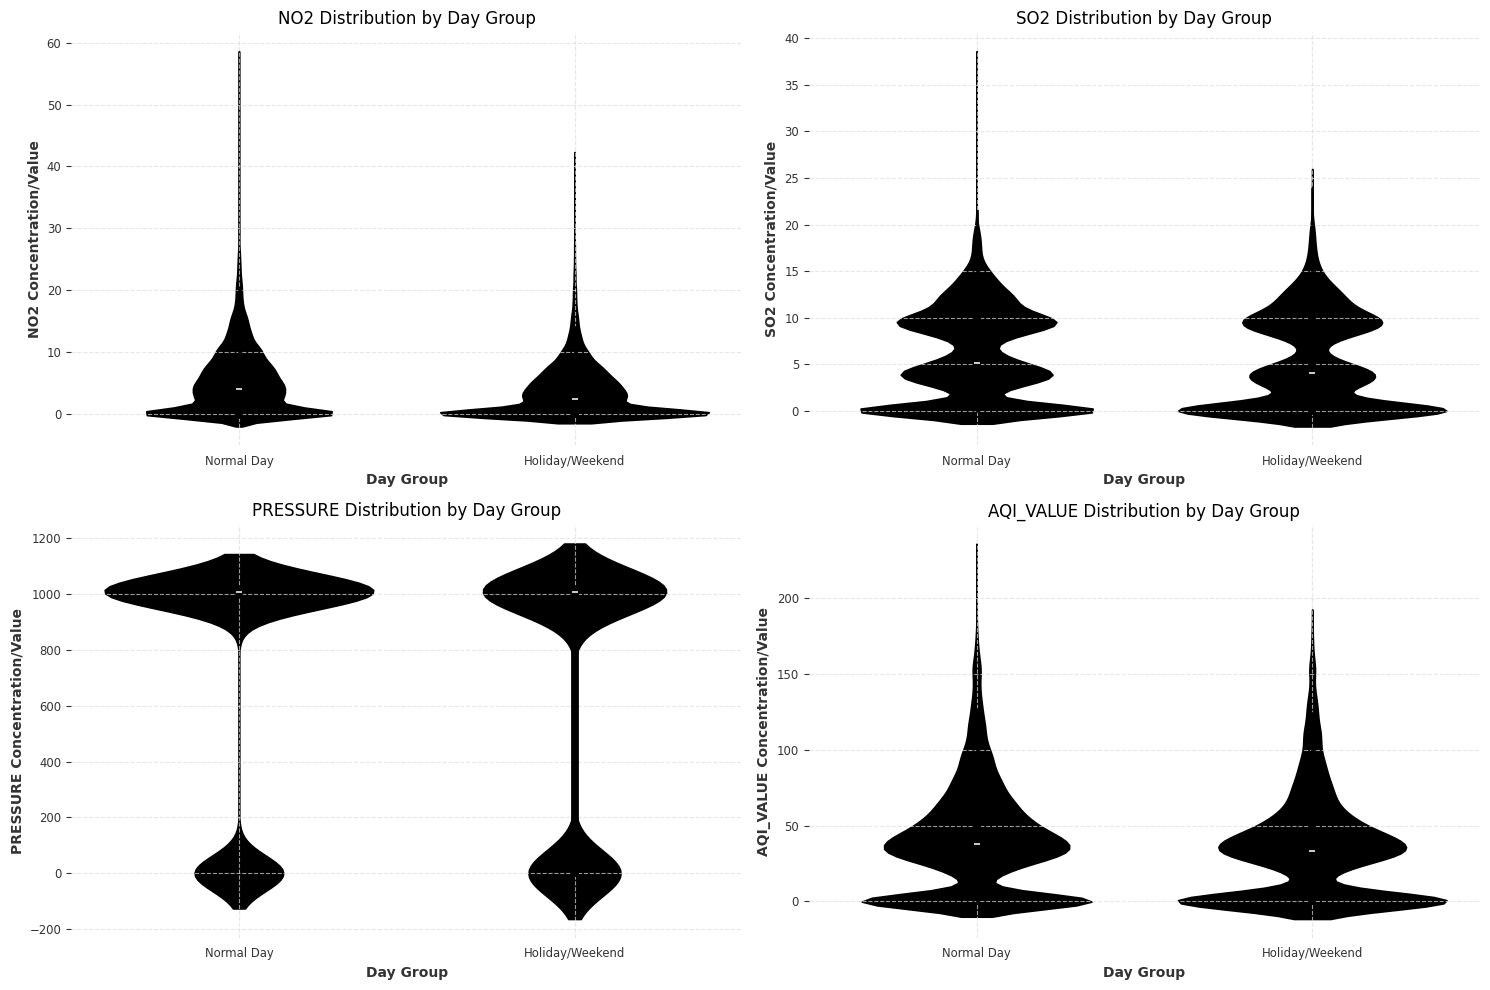

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# List of columns to visualize
columns_to_visualize = ['no2', 'so2', 'pressure', 'aqi_value']

# Create violin plots for each column
plt.figure(figsize=(15, 10))
for i, col in enumerate(columns_to_visualize):
    plt.subplot(2, 2, i + 1)
    sns.violinplot(x='day_group', y=col, data=df_KNN)
    plt.title(f'{col.upper()} Distribution by Day Group')
    plt.xlabel('Day Group')
    plt.ylabel(f'{col.upper()} Concentration/Value')
    plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

df_KNN['hour'] = df_KNN['DateTime'].dt.hour


df_KNN['day_night_group'] = np.where((df_KNN['hour'] >= 6) & (df_KNN['hour'] < 18), 'Day', 'Night')


print(df_KNN[['DateTime', 'hour', 'day_night_group']].head())


print("\nValue counts for 'day_night_group':")
print(df_KNN['day_night_group'].value_counts())

             DateTime  hour day_night_group
0 2022-11-01 00:30:00     0           Night
1 2022-11-01 01:30:00     1           Night
2 2022-11-01 02:30:00     2           Night
3 2022-11-01 03:30:00     3           Night
4 2022-11-01 04:30:00     4           Night

Value counts for 'day_night_group':
day_night_group
Day      11267
Night    11262
Name: count, dtype: int64


In [ ]:
mean_pm25_by_day_night_group = df_KNN.groupby('day_night_group')['pm2_5'].mean()

print("Mean PM2.5 Concentration by Day/Night Group:")
print(mean_pm25_by_day_night_group)

print(f"\nMean PM2.5 for Day: {mean_pm25_by_day_night_group['Day']:.2f}")
print(f"Mean PM2.5 for Night: {mean_pm25_by_day_night_group['Night']:.2f}")

Mean PM2.5 Concentration by Day/Night Group:
day_night_group
Day      17.490431
Night    18.194746
Name: pm2_5, dtype: float64

Mean PM2.5 for Day: 17.49
Mean PM2.5 for Night: 18.19


In [ ]:
from scipy.stats import f_oneway

# Separate pm2_5 values into two groups
pm25_day = df_KNN[df_KNN['day_night_group'] == 'Day']['pm2_5']
pm25_night = df_KNN[df_KNN['day_night_group'] == 'Night']['pm2_5']

# Perform one-way ANOVA test
f_statistic, p_value = f_oneway(pm25_day, pm25_night)

print(f"F-statistic: {f_statistic:.2f}")
print(f"P-value: {p_value:.3f}")

alpha = 0.05
if p_value < alpha:
    print("Conclusion: Reject the null hypothesis. There is a significant difference in mean pm2_5 concentrations between Day and Night groups.")
else:
    print("Conclusion: Fail to reject the null hypothesis. There is no significant difference in mean pm2_5 concentrations between Day and Night groups.")

F-statistic: 8.21
P-value: 0.004
Conclusion: Reject the null hypothesis. There is a significant difference in mean pm2_5 concentrations between Day and Night groups.


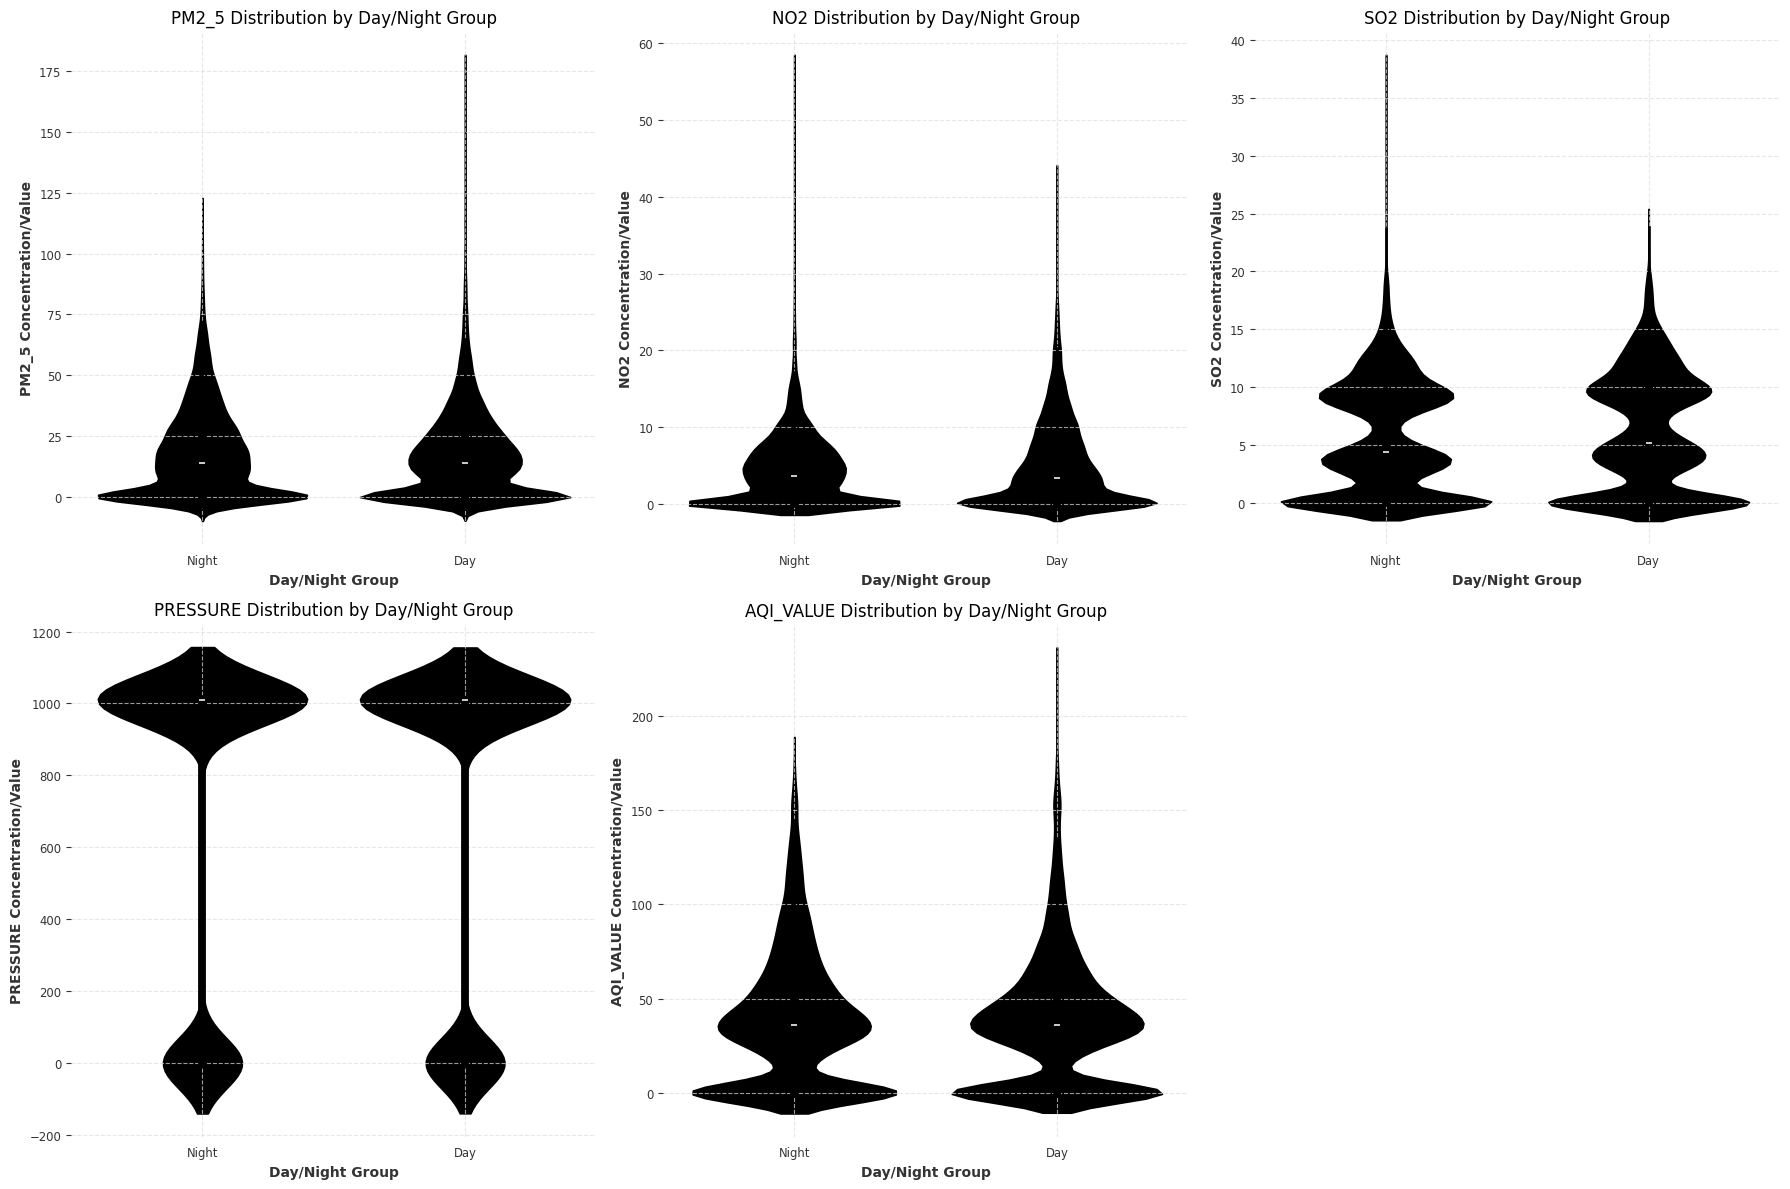

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# List of columns to visualize, including 'pm2_5'
columns_to_visualize_day_night = ['pm2_5', 'no2', 'so2', 'pressure', 'aqi_value']

# Create violin plots for each column
plt.figure(figsize=(18, 12))
for i, col in enumerate(columns_to_visualize_day_night):
    plt.subplot(2, 3, i + 1) # Arrange plots in a 2x3 grid
    sns.violinplot(x='day_night_group', y=col, data=df_KNN)
    plt.title(f'{col.upper()} Distribution by Day/Night Group')
    plt.xlabel('Day/Night Group')
    plt.ylabel(f'{col.upper()} Concentration/Value')
    plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
!pip install arch

from statsmodels.tsa.stattools import adfuller, kpss
from arch.unitroot import PhillipsPerron
import pandas as pd
import numpy as np

# Ensure the series is not empty and has no NaNs for the tests
# The pandas_hourly_series was already preprocessed for NaNs during seasonal decomposition.
if pandas_hourly_series.isnull().any():
    print("Warning: NaN values detected in pandas_hourly_series. Filling with mean for tests.")
    pandas_hourly_series_test = pandas_hourly_series.fillna(pandas_hourly_series.mean())
else:
    pandas_hourly_series_test = pandas_hourly_series.copy()

print("\n--- Augmented Dickey-Fuller (ADF) Test ---")
adf_result = adfuller(pandas_hourly_series_test)
print(f'ADF Statistic: {adf_result[0]:.2f}')
print(f'p-value: {adf_result[1]:.3f}')
print('Critical Values:')
for key, value in adf_result[4].items():
    print(f'    {key}: {value:.2f}')

if adf_result[1] < 0.05:
    print("Conclusion: Reject the null hypothesis. The series is stationary (no unit root).")
else:
    print("Conclusion: Fail to reject the null hypothesis. The series is non-stationary (has a unit root).")

print("\n--- Phillips-Perron (PP) Test ---")
# PhillipsPerron from arch library does not directly return p-value, but compares with critical values
pp_result = PhillipsPerron(pandas_hourly_series_test)
print(pp_result.summary())

# Interpret PP test (similar to ADF: p-value < 0.05 indicates stationarity)
# The summary provides the p-value. Assuming the 't-stat' and 'p-value' from the summary are the primary interpretation.
# For simplicity, we extract the p-value from the summary string or assume a similar interpretation as ADF.
# In arch, often you check if the test statistic is smaller than critical value.
# Let's extract the p-value from the summary table to be consistent with ADF.
pp_p_value_line = [line for line in pp_result.summary().as_text().split('\n') if 'P-value' in line]
pp_p_value = float(pp_p_value_line[0].split()[-1]) if pp_p_value_line else None

if pp_p_value is not None and pp_p_value < 0.05:
    print("Conclusion: Reject the null hypothesis. The series is stationary (no unit root).")
elif pp_p_value is not None:
    print("Conclusion: Fail to reject the null hypothesis. The series is non-stationary (has a unit root).")
else:
    print("Conclusion: Could not extract p-value from PP test for interpretation.")

print("\n--- Kwiatkowski-Phillips-Schmidt-Shin (KPSS) Test ---")
kpss_result = kpss(pandas_hourly_series_test)
print(f'KPSS Statistic: {kpss_result[0]:.2f}')
print(f'p-value: {kpss_result[1]:.3f}')
print('Critical Values:')
for key, value in kpss_result[3].items():
    print(f'    {key}: {value:.2f}')

# For KPSS, the null hypothesis is that the series is stationary.
# If p-value < 0.05, we reject the null (series is non-stationary).
if kpss_result[1] < 0.05:
    print("Conclusion: Reject the null hypothesis. The series is non-stationary (has a unit root).")
else:
    print("Conclusion: Fail to reject the null hypothesis. The series is stationary (no unit root).")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 1.1 MB/s eta 0:00:00

--- Augmented Dickey-Fuller (ADF) Test ---
ADF Statistic: -11.26
p-value: 0.000
Critical Values:
    1%: -3.43
    5%: -2.86
    10%: -2.57
Conclusion: Reject the null hypothesis. The series is stationary (no unit root).

--- Phillips-Perron (PP) Test ---
     Phillips-Perron Test (Z-tau)    
Test Statistic                -51.361
P-value                         0.000
Lags                               47
-------------------------------------

Trend: Constant
Critical Values: -3.43 (1%), -2.86 (5%), -2.57 (10%)
Null Hypothesis: The process contains a unit root.
Alternative Hypothesis: The process is weakly stationary.
Conclusion: Reject the null hypothesis. The series is stationary (no unit root).

--- Kwiatkowski-Phillips-Schmidt-Shin (KPSS) Test ---
KPSS Statistic: 0.83
p-value: 0.010
Critical Values:
    10%: 0.35
    5%: 0.46
    2.5%: 0.57
    1%: 0.74
Conclusion: Reject the null hypothesis. The series

/tmp/ipython-input-3904644139.py:50: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(pandas_hourly_series_test)


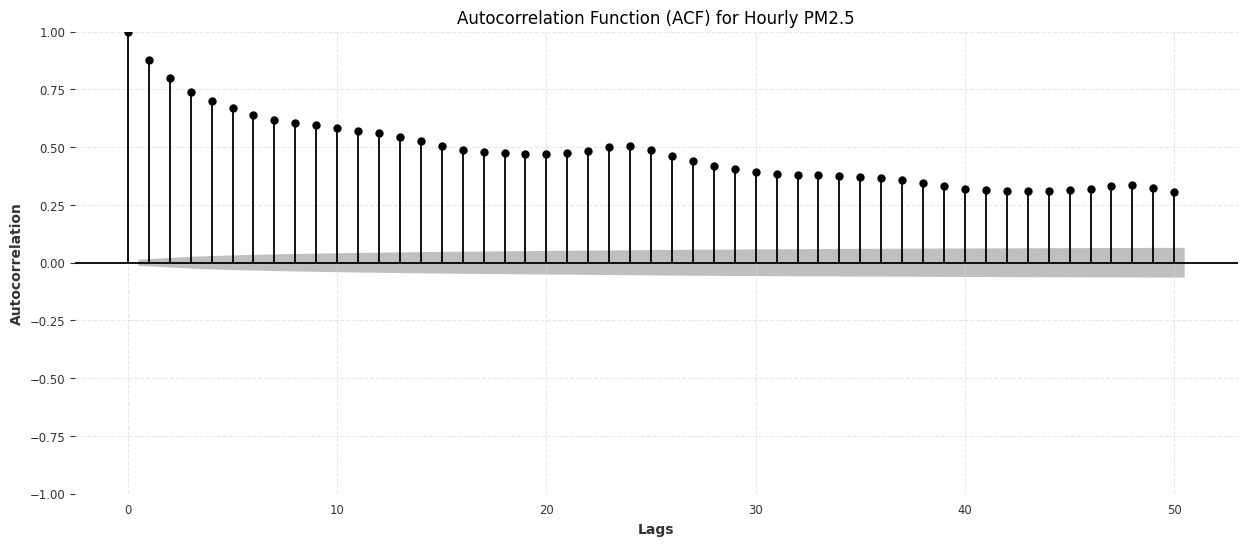

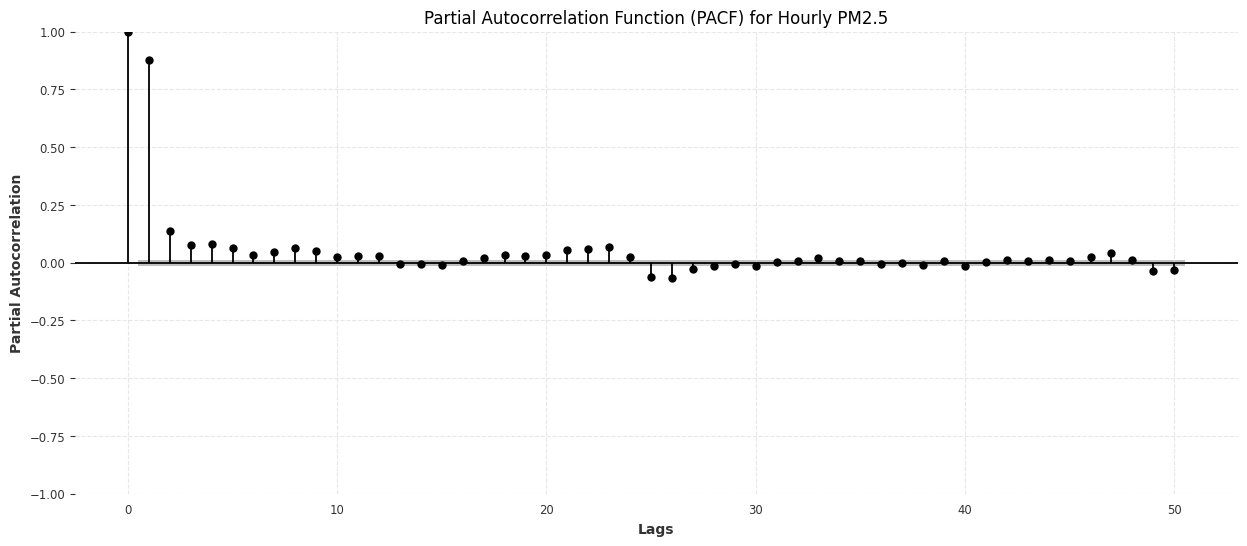

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# Create ACF plot
plt.figure(figsize=(15, 6))
plot_acf(pandas_hourly_series, lags=50, ax=plt.gca(), title='Autocorrelation Function (ACF) for Hourly PM2.5')
plt.xlabel('Lags')
plt.ylabel('Autocorrelation')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Create PACF plot
plt.figure(figsize=(15, 6))
plot_pacf(pandas_hourly_series, lags=50, ax=plt.gca(), title='Partial Autocorrelation Function (PACF) for Hourly PM2.5')
plt.xlabel('Lags')
plt.ylabel('Partial Autocorrelation')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()